<a href="https://colab.research.google.com/github/SamManuJacob/6thSem-ML-Lab/blob/main/1BM23CS291_Lab_5_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

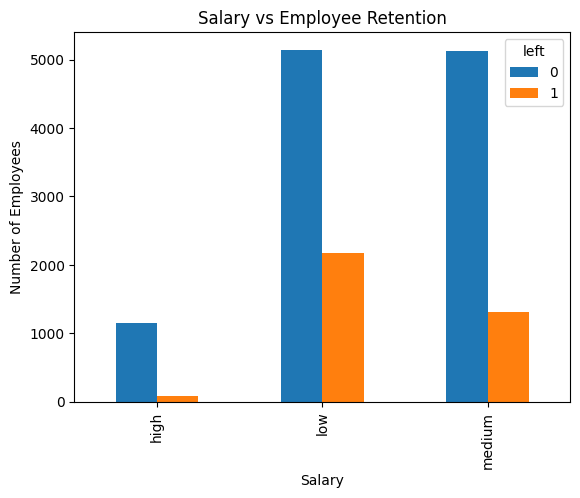

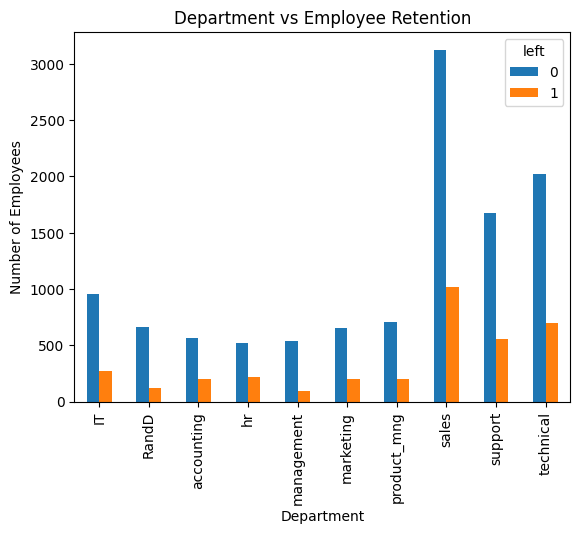

Binary Classification Accuracy: 0.762
Confusion Matrix:
 [[2124  170]
 [ 544  162]]


In [1]:
# ===============================
# Logistic Regression - Binary Classification
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Dataset
df = pd.read_csv("HR_comma_sep.csv")

# Display first 5 rows
print(df.head())

# -------------------------------
# Exploratory Data Analysis
# -------------------------------

# Check retention count
print(df['left'].value_counts())

# Impact of Salary on Retention
salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')
plt.title("Salary vs Employee Retention")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

# Impact of Department on Retention
dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar')
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

# -------------------------------
# Feature Selection
# -------------------------------

# Selecting important variables
df_model = df[['satisfaction_level',
               'average_montly_hours',
               'promotion_last_5years',
               'salary',
               'left']]

# Convert salary into dummy variables
df_model = pd.get_dummies(df_model, columns=['salary'], drop_first=True)

# Split Features and Target
X = df_model.drop('left', axis=1)
y = df_model['left']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# -------------------------------
# Model Building
# -------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Binary Classification Accuracy:", accuracy)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

First 5 rows:
   animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


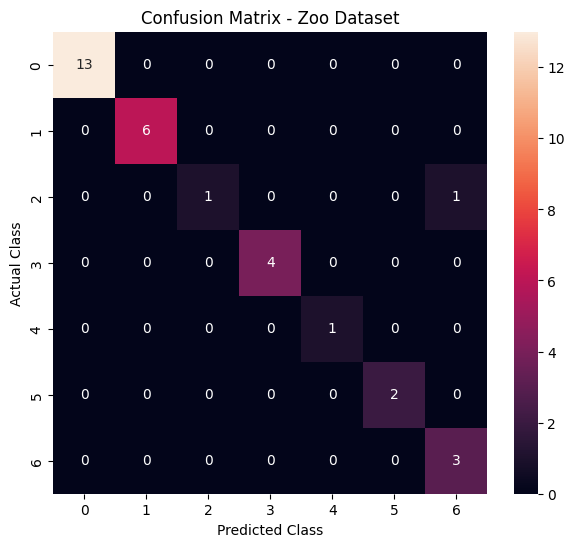

In [4]:
# ==========================================
# Logistic Regression – Multiclass (Zoo)
# With Scaling + Stratified Split
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklea  rn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Load Dataset
# -----------------------------

zoo = pd.read_csv("zoo-data.csv")

print("First 5 rows:\n", zoo.head())
print("\nDataset Info:\n")
print(zoo.info())

# -----------------------------
# Data Preprocessing
# -----------------------------

# Drop non-numeric column
zoo = zoo.drop("animal_name", axis=1)

# Check missing values
print("\nMissing Values:\n", zoo.isnull().sum())

# Features and Target
X = zoo.drop("class_type", axis=1)
y = zoo["class_type"]

# -----------------------------
# Train-Test Split (Stratified)
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build Logistic Regression Model
# -----------------------------

model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs'
)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# Accuracy
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)
print("\nMulticlass Classification Accuracy:", accuracy)

# -----------------------------
# Classification Report
# -----------------------------

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Zoo Dataset")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [5]:
# ==========================================
# Logistic Regression From Scratch (Binary)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("HR_comma_sep.csv")

# Select important features
df = df[['satisfaction_level',
         'average_montly_hours',
         'promotion_last_5years',
         'left']]

# Features and Target
X = df.drop('left', axis=1).values
y = df['left'].values.reshape(-1,1)

# -----------------------------
# Feature Scaling (Manual)
# -----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias column
X = np.c_[np.ones((X.shape[0],1)), X]

# -----------------------------
# Sigmoid Function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Initialize Parameters
# -----------------------------
weights = np.zeros((X.shape[1],1))
learning_rate = 0.01
epochs = 2000
m = len(y)

# -----------------------------
# Gradient Descent
# -----------------------------
for i in range(epochs):
    z = np.dot(X, weights)
    predictions = sigmoid(z)

    gradient = np.dot(X.T, (predictions - y)) / m
    weights -= learning_rate * gradient

# -----------------------------
# Predictions
# -----------------------------
z = np.dot(X, weights)
predictions = sigmoid(z)
y_pred = (predictions >= 0.5).astype(int)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = np.mean(y_pred == y)
print("Binary Classification Accuracy:", accuracy)

Binary Classification Accuracy: 0.7745849723314888


In [6]:
# ==========================================
# Logistic Regression From Scratch (Multiclass)
# ==========================================

import pandas as pd
import numpy as np

# -----------------------------
# Load Dataset
# -----------------------------
zoo = pd.read_csv("zoo-data.csv")

# Drop animal_name
zoo = zoo.drop("animal_name", axis=1)

X = zoo.drop("class_type", axis=1).values
y = zoo["class_type"].values

# Convert class labels to 0–6
y = y - 1

# -----------------------------
# One-Hot Encoding (Manual)
# -----------------------------
num_classes = len(np.unique(y))
m = len(y)

y_onehot = np.zeros((m, num_classes))
y_onehot[np.arange(m), y] = 1

# -----------------------------
# Feature Scaling
# -----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias column
X = np.c_[np.ones((X.shape[0],1)), X]

# -----------------------------
# Softmax Function
# -----------------------------
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# -----------------------------
# Initialize Weights
# -----------------------------
weights = np.zeros((X.shape[1], num_classes))
learning_rate = 0.01
epochs = 3000

# -----------------------------
# Gradient Descent
# -----------------------------
for i in range(epochs):
    z = np.dot(X, weights)
    predictions = softmax(z)

    gradient = np.dot(X.T, (predictions - y_onehot)) / m
    weights -= learning_rate * gradient

# -----------------------------
# Predictions
# -----------------------------
z = np.dot(X, weights)
predictions = softmax(z)
y_pred = np.argmax(predictions, axis=1)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = np.mean(y_pred == y)
print("Multiclass Classification Accuracy:", accuracy)

Multiclass Classification Accuracy: 1.0
